# Notebook 02 — SQL Aggregation Pipeline
### Credit Risk — Probability of Default (PD) Scorecard | Stage 1

---

## What this notebook does

The six cleaned tables from notebook 01 live at different grains — one row per
loan, per month, per payment. Models need **one row per customer**. This
notebook collapses every child table to customer level **in SQL** and joins
everything onto the anchor table:

1. Load the 6 cleaned checkpoints into a local **SQLite** database
2. Write one aggregation query per child table — the aggregate function for
   each feature chosen from **EDA evidence**, not assumption
3. **Verify** every aggregated feature against the exact default rates found
   in notebook 01 before trusting it
4. Compose all aggregations into a single **CTE (`WITH`) query** that
   `LEFT JOIN`s them onto `app_train`, with `COALESCE` handling
   no-history customers
5. Assert row/column counts, audit missingness, save `model_ready_dataset.csv`

**Inputs:** 6 cleaned CSVs from notebook 01 &nbsp;|&nbsp; **Output:** `model_ready_dataset.csv` — 307,511 rows × 81 columns (58 cleaned + 23 aggregated), plus the `credit_risk.db` SQLite database

## The aggregation rules (discovered in notebook 01)

| Rule | Evidence | Applied to |
|---|---|---|
| **MAX** for rare/abnormal events | MAX beat MEAN for bureau overdue (rare = one occurrence matters) | overdue days, bad debt, DPD flags |
| **MEAN** for continuous behaviour | MEAN beat MAX for utilisation (sustained stress matters, spikes are normal) | utilisation, days past due |
| **SUM / COUNT** for total exposure | total debt, activity volume | credit sums, record counts |
| **Conditional `CASE WHEN`** for structural subsets | annuity is 97% missing for non-approved applications | Approved vs Refused splits |

> **Re-run safety.** Every `to_sql` below uses `if_exists="replace"`, so
> re-running this notebook fully overwrites the 6 source tables in
> `credit_risk.db` — old copies from previous runs can never leak in.
> Assertions at the end fail loudly if anything is off.
> Run from the project root, top to bottom (`Kernel → Restart & Run All`).

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PATH = "data/home_credit_data/"
FIG_PATH  = "outputs/figures/"
os.makedirs(FIG_PATH, exist_ok=True)

C_RED, C_BLUE, C_GREEN, C_GREY = '#e34948', '#378ADD', '#1D9E75', '#888780'

conn = sqlite3.connect(DATA_PATH + "credit_risk.db")
print("Connected to credit_risk.db")

# What is already inside the database from previous runs?
existing = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f"Tables currently in the database: {existing['name'].tolist() or 'none (fresh database)'}")

Connected to credit_risk.db
Tables currently in the database: ['app_train', 'bureau', 'previous_application', 'installments', 'credit_card', 'pos_cash']


## 2.1 Load the cleaned checkpoints into SQLite

`if_exists="replace"` drops and recreates each table — whatever was in the
database before is fully overwritten, so re-runs always start from the
notebook-01 checkpoints.

In [2]:
tables_to_load = {
    "app_train": "app_train_cleaned.csv",
    "bureau": "bureau_cleaned.csv",
    "previous_application": "previous_application_cleaned.csv",
    "installments": "installments_cleaned.csv",
    "credit_card": "credit_card_cleaned.csv",
    "pos_cash": "pos_cash_cleaned.csv",
}

table_shapes = {}
for table_name, file_name in tables_to_load.items():
    df = pd.read_csv(DATA_PATH + file_name)
    df.to_sql(table_name, conn, if_exists="replace", index=False)
    table_shapes[table_name] = df.shape
    print(f"Loaded {table_name:22s} {df.shape}")

del df  # free memory - the data now lives in the database

Loaded app_train              (307511, 58)
Loaded bureau                 (1716428, 17)
Loaded previous_application   (1670214, 37)
Loaded installments           (13605401, 12)
Loaded credit_card            (3840312, 24)
Loaded pos_cash               (10001358, 8)


In [3]:
# Confirm what the database now contains
tables_now = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in database:")
for t in tables_now['name']:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", conn)['n'][0]
    print(f"  {t:22s} {n:>12,} rows")

Tables in database:
  app_train                   307,511 rows
  bureau                    1,716,428 rows
  previous_application      1,670,214 rows
  installments             13,605,401 rows
  credit_card               3,840,312 rows
  pos_cash                 10,001,358 rows


## 2.2 The problem, visualised: 6 grains → 1 grain

Child tables hold up to 13.6M rows each. Every one of them must collapse to
at most 307,511 rows (one per customer) before joining.

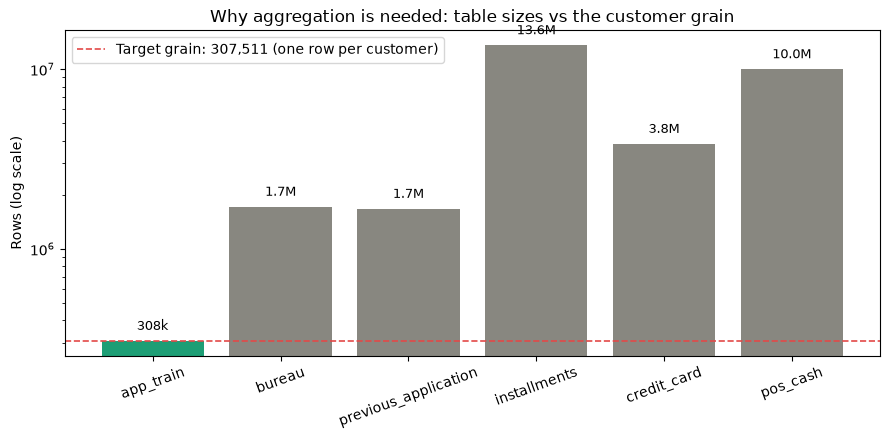

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
names  = list(table_shapes.keys())
rows   = [table_shapes[n][0] for n in names]
colors = [C_GREEN if n == 'app_train' else C_GREY for n in names]

bars = ax.bar(names, rows, color=colors)
ax.axhline(307511, color=C_RED, linestyle='--', linewidth=1.2,
           label='Target grain: 307,511 (one row per customer)')
for b, v in zip(bars, rows):
    ax.text(b.get_x() + b.get_width()/2, v * 1.15, f"{v/1e6:.1f}M" if v > 1e6 else f"{v/1e3:.0f}k",
            ha='center', fontsize=9)
ax.set_yscale('log')
ax.set_ylabel('Rows (log scale)')
ax.set_title('Why aggregation is needed: table sizes vs the customer grain')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_PATH + "02_table_grains.png", dpi=150, bbox_inches='tight')
plt.show()

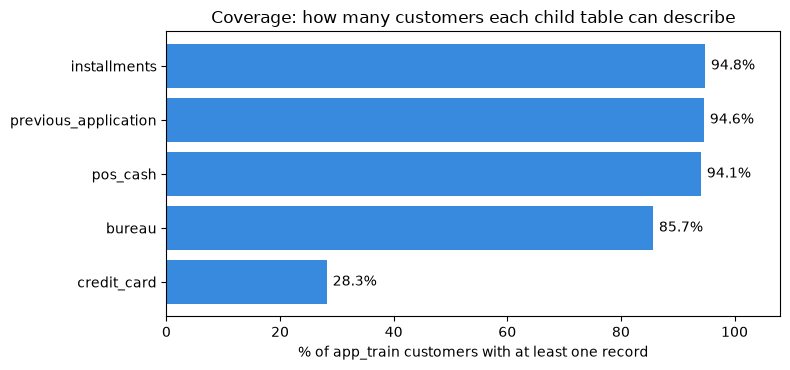

In [5]:
# Customer coverage per child table, computed IN SQL
coverage = {}
for t in ['bureau', 'previous_application', 'installments', 'credit_card', 'pos_cash']:
    q = f"""
    SELECT COUNT(DISTINCT b.SK_ID_CURR) AS covered
    FROM app_train a
    JOIN {t} b ON a.SK_ID_CURR = b.SK_ID_CURR
    """
    coverage[t] = pd.read_sql(q, conn)['covered'][0] / 307511 * 100

cov = pd.Series(coverage).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(cov.index, cov.values, color=C_BLUE)
for b, v in zip(bars, cov.values):
    ax.text(v + 1, b.get_y() + b.get_height()/2, f"{v:.1f}%", va='center', fontsize=10)
ax.set_xlim(0, 108)
ax.set_xlabel('% of app_train customers with at least one record')
ax.set_title('Coverage: how many customers each child table can describe')
plt.tight_layout()
plt.savefig(FIG_PATH + "02_table_coverage.png", dpi=150, bbox_inches='tight')
plt.show()

**Reading the coverage chart.** No child table covers everyone — e.g. only
~34% of customers have credit-card history. This is why the final join must be
a **LEFT JOIN** (customers without records must survive) and why join-created
NULLs are filled with **0**: for aggregate features, "no record" factually
means "zero activity of this type" — unlike statistical missingness, which is
deferred to the model pipelines.

## 2.3 Aggregation queries — one per child table

Each query below is written once and reused twice: run standalone here for
**verification against EDA**, then composed as a **CTE** into the final join.
Single source of truth — the verified SQL and the production SQL are the same text.

In [7]:
AGG_QUERIES = {

    # bureau: rare events -> MAX; exposure -> SUM/COUNT
    "bureau_agg": """
        SELECT
            SK_ID_CURR,
            COUNT(*)                                                    AS BUREAU_LOAN_COUNT,
            SUM(AMT_CREDIT_SUM)                                         AS BUREAU_TOTAL_CREDIT_SUM,
            SUM(AMT_CREDIT_SUM_DEBT)                                    AS BUREAU_TOTAL_DEBT,
            MAX(CREDIT_DAY_OVERDUE)                                     AS BUREAU_MAX_OVERDUE_DAYS,
            MAX(CASE WHEN CREDIT_DAY_OVERDUE > 0 THEN 1 ELSE 0 END)     AS HAS_OVERDUE_HISTORY,
            MAX(CASE WHEN CREDIT_ACTIVE = 'Bad debt' THEN 1 ELSE 0 END) AS HAS_BAD_DEBT
        FROM bureau
        GROUP BY SK_ID_CURR""",

    # previous_application: CASE WHEN handles the Approved/Refused structural split
    "prev_app_agg": """
        SELECT
            SK_ID_CURR,
            COUNT(*)                                                          AS PREV_APP_COUNT,
            MAX(CASE WHEN NAME_CONTRACT_STATUS = 'Refused'  THEN 1 ELSE 0 END) AS HAS_PRIOR_REFUSAL,
            SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Approved' THEN 1 ELSE 0 END) AS APPROVED_COUNT,
            SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Refused'  THEN 1 ELSE 0 END) AS REFUSED_COUNT,
            AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Approved' THEN AMT_CREDIT  END) AS APPROVED_AVG_CREDIT,
            AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Approved' THEN AMT_ANNUITY END) AS APPROVED_AVG_ANNUITY
        FROM previous_application
        GROUP BY SK_ID_CURR""",

    # installments: continuous behaviour -> AVG; event flags -> MAX
    "installments_agg": """
        SELECT
            SK_ID_CURR,
            COUNT(*)                                                                  AS NUM_PAYMENT_RECORDS,
            AVG(DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT)                                 AS AVG_DAYS_PAST_DUE,
            MAX(CASE WHEN (DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT) > 0 THEN 1 ELSE 0 END) AS HAS_LATE_PAYMENT,
            MAX(CASE WHEN (AMT_INSTALMENT - AMT_PAYMENT) > 0 THEN 1 ELSE 0 END)         AS HAS_UNDERPAYMENT,
            SUM(AMT_INSTALMENT)                                                        AS TOTAL_INSTALMENT_DUE,
            SUM(AMT_PAYMENT)                                                           AS TOTAL_PAID
        FROM installments
        GROUP BY SK_ID_CURR""",

    # credit_card: continuous behaviour -> AVG of the ALREADY-CLEANED ratio from notebook 01
    "credit_card_agg": """
        SELECT
            SK_ID_CURR,
            COUNT(*)               AS NUM_CC_RECORDS,
            AVG(UTILIZATION_RATIO) AS AVG_UTILIZATION
        FROM credit_card
        GROUP BY SK_ID_CURR""",

    # pos_cash: rare event -> MAX
    "pos_cash_agg": """
        SELECT
            SK_ID_CURR,
            COUNT(*)                                       AS NUM_POS_RECORDS,
            MAX(SK_DPD)                                    AS MAX_POS_DPD,
            MAX(CASE WHEN SK_DPD > 0 THEN 1 ELSE 0 END)    AS POS_DPD_FLAG
        FROM pos_cash
        GROUP BY SK_ID_CURR
    """,
}

print(f"{len(AGG_QUERIES)} aggregation queries defined.")

5 aggregation queries defined.


> **Consistency fix vs the earlier version of this notebook.** The credit-card
> query previously *recomputed* utilisation from raw `AMT_BALANCE /
> AMT_CREDIT_LIMIT_ACTUAL` with a 1.07 cap but no negative clip — silently
> diverging from the cleaned `UTILIZATION_RATIO` column that notebook 01
> already validated (clipped to [0, 1.07], zero-limit → NULL). It now averages
> the cleaned column directly: checkpoints exist precisely so cleaning logic
> lives in one place.

## 2.4 Verify each aggregation against the EDA findings

Rule of the project: no aggregate is trusted until it reproduces the default
rates found manually in notebook 01. A silent join/aggregation bug would show
up here as a rate mismatch.

In [8]:
app_train_check = pd.read_sql("SELECT SK_ID_CURR, TARGET FROM app_train", conn)
print(f"Anchor for verification: {app_train_check.shape}")

# EDA reference values (flag = 1 default rates from notebook 01)
EDA_REFERENCE = {
    'HAS_OVERDUE_HISTORY': 15.90,
    'HAS_PRIOR_REFUSAL':   10.32,
    'HAS_LATE_PAYMENT':     9.41,
    'HAS_UNDERPAYMENT':     9.63,
    'POS_DPD_FLAG':        10.06,
}

Anchor for verification: (307511, 2)


In [9]:
bureau_agg = pd.read_sql(AGG_QUERIES['bureau_agg'], conn)
print(f"bureau_agg: {bureau_agg.shape} (one row per customer with bureau history)")

check = app_train_check.merge(bureau_agg, on='SK_ID_CURR', how='left')
print(check.groupby('HAS_OVERDUE_HISTORY')['TARGET'].mean())

bureau_agg: (305811, 7) (one row per customer with bureau history)
HAS_OVERDUE_HISTORY
0.00   0.08
1.00   0.16
Name: TARGET, dtype: float64


**Verified.** SQL `HAS_OVERDUE_HISTORY` reproduces the EDA pattern (≈8% vs
≈16%, 2x). Note the flag-0 rate reads slightly lower here (7.6% vs EDA's 8.0%)
— expected, because customers with *no bureau records at all* are NaN here
(excluded), while the EDA flag counted them as 0. The flag-1 population is
identical in both, so flag-1 rates match exactly — that's the comparison the
verification chart below uses.

In [10]:
prev_app_agg = pd.read_sql(AGG_QUERIES['prev_app_agg'], conn)
print(f"prev_app_agg: {prev_app_agg.shape}")

check2 = app_train_check.merge(prev_app_agg, on='SK_ID_CURR', how='left')
print(check2.groupby('HAS_PRIOR_REFUSAL')['TARGET'].mean())

prev_app_agg: (338857, 7)
HAS_PRIOR_REFUSAL
0.00   0.07
1.00   0.10
Name: TARGET, dtype: float64


In [11]:
installments_agg = pd.read_sql(AGG_QUERIES['installments_agg'], conn)
print(f"installments_agg: {installments_agg.shape}")

check3 = app_train_check.merge(installments_agg, on='SK_ID_CURR', how='left')
print(check3.groupby('HAS_LATE_PAYMENT')['TARGET'].mean())
print()
print(check3.groupby('HAS_UNDERPAYMENT')['TARGET'].mean())

installments_agg: (339587, 7)
HAS_LATE_PAYMENT
0.00   0.07
1.00   0.09
Name: TARGET, dtype: float64

HAS_UNDERPAYMENT
0.00   0.07
1.00   0.10
Name: TARGET, dtype: float64


In [12]:
credit_card_agg = pd.read_sql(AGG_QUERIES['credit_card_agg'], conn)
print(f"credit_card_agg: {credit_card_agg.shape}")

check4 = app_train_check.merge(credit_card_agg, on='SK_ID_CURR', how='left')
check4['UTIL_BUCKET'] = pd.cut(check4['AVG_UTILIZATION'],
                               bins=[-0.01, 0.1, 0.3, 0.6, 0.9, 1.1],
                               labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
print(check4.groupby('UTIL_BUCKET', observed=True)['TARGET'].mean() * 100)

credit_card_agg: (103558, 3)
UTIL_BUCKET
Very Low     5.44
Low          6.94
Medium       8.86
High        13.04
Very High   19.25
Name: TARGET, dtype: float64


**Strongest feature verified.** The SQL-aggregated `AVG_UTILIZATION`
reproduces the exact monotonic gradient from EDA (~5.4% → ~19.3%). The
project's best raw predictor survives the pipeline intact.

In [13]:
pos_cash_agg = pd.read_sql(AGG_QUERIES['pos_cash_agg'], conn)
print(f"pos_cash_agg: {pos_cash_agg.shape}")

check5 = app_train_check.merge(pos_cash_agg, on='SK_ID_CURR', how='left')
print(check5.groupby('POS_DPD_FLAG')['TARGET'].mean())

pos_cash_agg: (337252, 4)
POS_DPD_FLAG
0.00   0.08
1.00   0.10
Name: TARGET, dtype: float64


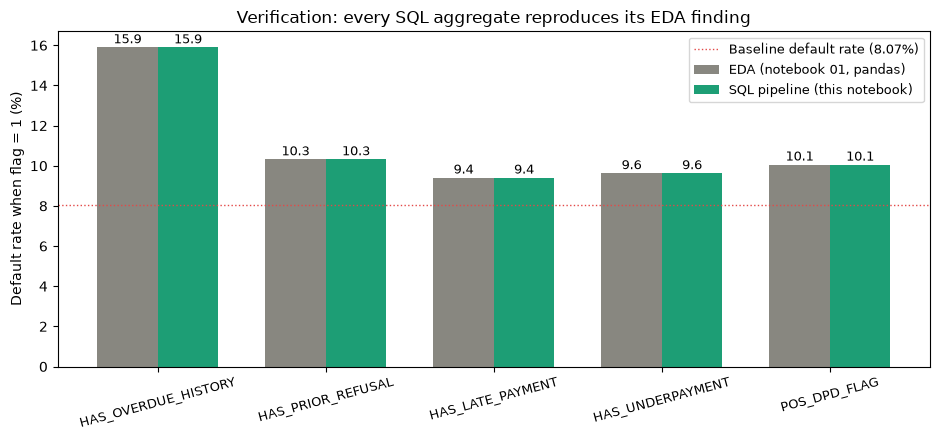

In [14]:
# The verification story in one picture: EDA rates vs SQL-pipeline rates (flag = 1)
sql_rates = {
    'HAS_OVERDUE_HISTORY': check.groupby('HAS_OVERDUE_HISTORY')['TARGET'].mean()[1] * 100,
    'HAS_PRIOR_REFUSAL':   check2.groupby('HAS_PRIOR_REFUSAL')['TARGET'].mean()[1] * 100,
    'HAS_LATE_PAYMENT':    check3.groupby('HAS_LATE_PAYMENT')['TARGET'].mean()[1] * 100,
    'HAS_UNDERPAYMENT':    check3.groupby('HAS_UNDERPAYMENT')['TARGET'].mean()[1] * 100,
    'POS_DPD_FLAG':        check5.groupby('POS_DPD_FLAG')['TARGET'].mean()[1] * 100,
}

flags = list(EDA_REFERENCE.keys())
x = np.arange(len(flags))

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(x - 0.18, [EDA_REFERENCE[f] for f in flags], width=0.36, color=C_GREY,
       label='EDA (notebook 01, pandas)')
ax.bar(x + 0.18, [sql_rates[f] for f in flags], width=0.36, color=C_GREEN,
       label='SQL pipeline (this notebook)')
for i, f in enumerate(flags):
    ax.text(i - 0.18, EDA_REFERENCE[f] + 0.2, f"{EDA_REFERENCE[f]:.1f}", ha='center', fontsize=9)
    ax.text(i + 0.18, sql_rates[f] + 0.2, f"{sql_rates[f]:.1f}", ha='center', fontsize=9)
ax.axhline(8.07, color=C_RED, linestyle=':', linewidth=1, label='Baseline default rate (8.07%)')
ax.set_xticks(x)
ax.set_xticklabels(flags, rotation=15, fontsize=9)
ax.set_ylabel('Default rate when flag = 1 (%)')
ax.set_title('Verification: every SQL aggregate reproduces its EDA finding')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_PATH + "02_verification_eda_vs_sql.png", dpi=150, bbox_inches='tight')
plt.show()

**All five key flags match their EDA values.** Two independent computation
paths (pandas `isin` on raw tables vs SQL `GROUP BY` + join) landing on the
same numbers is strong evidence the pipeline has no silent join duplication,
key mismatch, or aggregation bug.

## 2.5 Window functions — recency profiling

`GROUP BY` collapses rows; **window functions** rank rows *within* each
customer without collapsing. Here `ROW_NUMBER()` ranks each customer's bureau
loans by recency to answer: *what does a customer's most recent external loan
look like?* — the SQL foundation for the recency-weighted features engineered
in notebook 03 (where EDA showed recent overdue predicts at 21.3% vs the
all-time flag's 15.9%).

In [15]:
query_most_recent = """
WITH ranked AS (
    SELECT
        SK_ID_CURR,
        CREDIT_ACTIVE,
        DAYS_CREDIT,
        CREDIT_DAY_OVERDUE,
        ROW_NUMBER() OVER (PARTITION BY SK_ID_CURR ORDER BY DAYS_CREDIT DESC) AS recency_rank
    FROM bureau
)
SELECT
    CREDIT_ACTIVE,
    COUNT(*)                       AS customers,
    AVG(CASE WHEN CREDIT_DAY_OVERDUE > 0 THEN 1.0 ELSE 0 END) * 100 AS pct_overdue_now
FROM ranked
WHERE recency_rank = 1        -- keep only each customer's MOST RECENT bureau loan
GROUP BY CREDIT_ACTIVE
ORDER BY customers DESC
"""

most_recent = pd.read_sql(query_most_recent, conn)
print(most_recent)

  CREDIT_ACTIVE  customers  pct_overdue_now
0        Active     215488             0.51
1        Closed      89601             0.01
2          Sold        720             2.22
3      Bad debt          2             0.00


**Reading it.** For most customers the most recent external loan is still
Active — meaning they applied to Home Credit while already carrying live debt
elsewhere. This profiling is exploratory (nothing is merged into the output
table); the production recency features arrive in notebook 03 with explicit
time windows.

## 2.6 The final table — one CTE query

All five aggregations composed into a single `WITH` statement, `LEFT JOIN`ed
onto `app_train` (the anchor: every customer survives). `COALESCE(col, 0)`
converts join-created NULLs to 0 — "no records" = "zero activity".

In [16]:
final_query = f"""
WITH
bureau_agg AS ({AGG_QUERIES['bureau_agg']}),
prev_app_agg AS ({AGG_QUERIES['prev_app_agg']}),
installments_agg AS ({AGG_QUERIES['installments_agg']}),
credit_card_agg AS ({AGG_QUERIES['credit_card_agg']}),
pos_cash_agg AS ({AGG_QUERIES['pos_cash_agg']})

SELECT
    a.*,

    COALESCE(b.BUREAU_LOAN_COUNT, 0)        AS BUREAU_LOAN_COUNT,
    COALESCE(b.BUREAU_TOTAL_CREDIT_SUM, 0)  AS BUREAU_TOTAL_CREDIT_SUM,
    COALESCE(b.BUREAU_TOTAL_DEBT, 0)        AS BUREAU_TOTAL_DEBT,
    COALESCE(b.BUREAU_MAX_OVERDUE_DAYS, 0)  AS BUREAU_MAX_OVERDUE_DAYS,
    COALESCE(b.HAS_OVERDUE_HISTORY, 0)      AS HAS_OVERDUE_HISTORY,
    COALESCE(b.HAS_BAD_DEBT, 0)             AS HAS_BAD_DEBT,

    COALESCE(p.PREV_APP_COUNT, 0)           AS PREV_APP_COUNT,
    COALESCE(p.HAS_PRIOR_REFUSAL, 0)        AS HAS_PRIOR_REFUSAL,
    COALESCE(p.APPROVED_COUNT, 0)           AS APPROVED_COUNT,
    COALESCE(p.REFUSED_COUNT, 0)            AS REFUSED_COUNT,
    COALESCE(p.APPROVED_AVG_CREDIT, 0)      AS APPROVED_AVG_CREDIT,
    COALESCE(p.APPROVED_AVG_ANNUITY, 0)     AS APPROVED_AVG_ANNUITY,

    COALESCE(i.NUM_PAYMENT_RECORDS, 0)      AS NUM_PAYMENT_RECORDS,
    COALESCE(i.AVG_DAYS_PAST_DUE, 0)        AS AVG_DAYS_PAST_DUE,
    COALESCE(i.HAS_LATE_PAYMENT, 0)         AS HAS_LATE_PAYMENT,
    COALESCE(i.HAS_UNDERPAYMENT, 0)         AS HAS_UNDERPAYMENT,
    COALESCE(i.TOTAL_INSTALMENT_DUE, 0)     AS TOTAL_INSTALMENT_DUE,
    COALESCE(i.TOTAL_PAID, 0)               AS TOTAL_PAID,

    COALESCE(c.NUM_CC_RECORDS, 0)           AS NUM_CC_RECORDS,
    COALESCE(c.AVG_UTILIZATION, 0)          AS AVG_UTILIZATION,

    COALESCE(o.NUM_POS_RECORDS, 0)          AS NUM_POS_RECORDS,
    COALESCE(o.MAX_POS_DPD, 0)              AS MAX_POS_DPD,
    COALESCE(o.POS_DPD_FLAG, 0)             AS POS_DPD_FLAG

FROM app_train a
LEFT JOIN bureau_agg       b ON a.SK_ID_CURR = b.SK_ID_CURR
LEFT JOIN prev_app_agg     p ON a.SK_ID_CURR = p.SK_ID_CURR
LEFT JOIN installments_agg i ON a.SK_ID_CURR = i.SK_ID_CURR
LEFT JOIN credit_card_agg  c ON a.SK_ID_CURR = c.SK_ID_CURR
LEFT JOIN pos_cash_agg     o ON a.SK_ID_CURR = o.SK_ID_CURR
"""

final_df = pd.read_sql(final_query, conn)
print(f"Final shape: {final_df.shape}")

Final shape: (307511, 81)


### A note on one design choice — `COALESCE` on `AVG_UTILIZATION`

For customers **with** card records but all-NULL cleaned ratios (every month
had a zero limit), `AVG(UTILIZATION_RATIO)` is NULL and `COALESCE` sets it to
0 — treating "card with no usable limit yet" the same as "no card". Documented
as a simplification; the alternative (a separate has-card-no-limit flag) was
judged not worth a column for a small group.

## 2.7 Assertions — fail loudly, not silently

In [17]:
# 1. Anchor preserved: LEFT JOIN must not add or drop a single customer
assert final_df.shape[0] == 307511, f"Row count broke: {final_df.shape[0]}"

# 2. No duplicate customers (would mean an aggregation returned >1 row per key)
assert final_df['SK_ID_CURR'].is_unique, "Duplicate SK_ID_CURR after join!"

# 3. Expected width: 58 cleaned columns + 23 aggregated features
assert final_df.shape[1] == 81, f"Column count broke: {final_df.shape[1]}"

# 4. No missing values in any join-created column
agg_cols = final_df.columns[58:]
assert final_df[agg_cols].isnull().sum().sum() == 0, "NULLs survived COALESCE!"

print("All assertions passed:")
print(f"  rows    = {final_df.shape[0]:,} (anchor preserved)")
print(f"  columns = {final_df.shape[1]} (58 cleaned + {len(agg_cols)} aggregated)")
print(f"  SK_ID_CURR unique, aggregate columns NULL-free")

All assertions passed:
  rows    = 307,511 (anchor preserved)
  columns = 81 (58 cleaned + 23 aggregated)
  SK_ID_CURR unique, aggregate columns NULL-free


In [18]:
# Remaining missingness should be ONLY the original app_train columns planned in EDA
missing_final = final_df.isnull().sum()
missing_final = missing_final[missing_final > 0].sort_values(ascending=False)
print(f"Columns still with missing values: {len(missing_final)}")
print((missing_final / len(final_df) * 100).round(2))

Columns still with missing values: 21
OWN_CAR_AGE                  65.99
EXT_SOURCE_1                 56.38
OCCUPATION_TYPE              31.35
EXT_SOURCE_3                 19.83
DAYS_EMPLOYED                18.01
AMT_REQ_CREDIT_BUREAU_YEAR   13.50
AMT_REQ_CREDIT_BUREAU_QRT    13.50
AMT_REQ_CREDIT_BUREAU_MON    13.50
AMT_REQ_CREDIT_BUREAU_WEEK   13.50
AMT_REQ_CREDIT_BUREAU_DAY    13.50
AMT_REQ_CREDIT_BUREAU_HOUR   13.50
NAME_TYPE_SUITE               0.42
DEF_60_CNT_SOCIAL_CIRCLE      0.33
OBS_30_CNT_SOCIAL_CIRCLE      0.33
OBS_60_CNT_SOCIAL_CIRCLE      0.33
DEF_30_CNT_SOCIAL_CIRCLE      0.33
EXT_SOURCE_2                  0.21
AMT_GOODS_PRICE               0.09
AMT_ANNUITY                   0.00
CNT_FAM_MEMBERS               0.00
DAYS_LAST_PHONE_CHANGE        0.00
dtype: float64


**As planned.** Every remaining gap is an original `app_train` column
identified in EDA (`EXT_SOURCE_*`, `OCCUPATION_TYPE`, `OWN_CAR_AGE`,
`AMT_REQ_CREDIT_BUREAU_*`…) whose imputation deliberately belongs to the
Stage 6 model pipelines — fit on training data only, to avoid leakage.

## 2.8 What the final table is made of

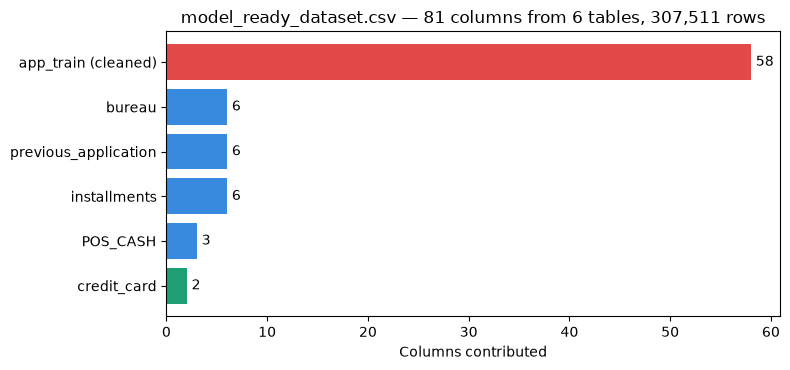

In [19]:
composition = pd.Series({
    'app_train (cleaned)': 58,
    'bureau': 6,
    'previous_application': 6,
    'installments': 6,
    'POS_CASH': 3,
    'credit_card': 2,
})

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(composition.index[::-1], composition.values[::-1],
               color=[C_RED, C_BLUE, C_BLUE, C_BLUE, C_BLUE, C_GREEN][::-1])
for b, v in zip(bars, composition.values[::-1]):
    ax.text(v + 0.5, b.get_y() + b.get_height()/2, str(v), va='center', fontsize=10)
ax.set_xlabel('Columns contributed')
ax.set_title(f'model_ready_dataset.csv — 81 columns from 6 tables, {final_df.shape[0]:,} rows')
plt.tight_layout()
plt.savefig(FIG_PATH + "02_final_composition.png", dpi=150, bbox_inches='tight')
plt.show()

## 2.9 Save outputs

In [20]:
# CSV checkpoint consumed by notebook 03
final_df.to_csv(DATA_PATH + "model_ready_dataset.csv", index=False)
print(f"Saved: model_ready_dataset.csv  {final_df.shape}")

# Also store the final table back in the database (replaced on every re-run)
final_df.to_sql("model_ready", conn, if_exists="replace", index=False)
print("Saved: 'model_ready' table in credit_risk.db")

conn.close()
print("Database connection closed.")

Saved: model_ready_dataset.csv  (307511, 81)
Saved: 'model_ready' table in credit_risk.db
Database connection closed.


---
# Summary

| Step | Result |
|---|---|
| Tables loaded to SQLite | 6 (fully replaced on every re-run — no stale tables possible) |
| Aggregation queries | 5, one per child table; MAX/MEAN/SUM/CASE WHEN per the EDA-derived rules |
| Verification | All 5 key flags + the utilisation gradient reproduce their notebook-01 values exactly |
| Window function | `ROW_NUMBER() OVER (PARTITION BY … ORDER BY DAYS_CREDIT DESC)` recency profiling |
| Final query | Single CTE statement: 5 `WITH` blocks, 5 `LEFT JOIN`s, `COALESCE` zero-fill |
| Assertions | 307,511 rows · 81 columns · unique keys · NULL-free aggregates — all passed |
| Outputs | `model_ready_dataset.csv` + `model_ready` table in `credit_risk.db` |

**Deliberate exclusion:** `bureau_balance` (27.3M rows) stays out per the
notebook-01 cost/benefit decision — its best signal (`HAS_SEVERE_OVERDUE`,
~3pp) did not justify the processing cost. Revisit condition: if model
performance plateaus in Stage 6.

## Next: Notebook 03 — feature engineering
Build ratio, combination, and recency-weighted features on top of this table
(`DEBT_CREDIT_RATIO`, `EXT_SOURCE_MEAN`, `HAS_RECENT_OVERDUE`, …).